In [1]:
import sys
sys.path.append('../')

import starry.utils.env

In [2]:
import os
import torch


TRAINING_DIR = os.environ.get('TRAINING_DIR')

model = torch.jit.load(os.path.join(TRAINING_DIR, 'paraff/20241213-midiseq-paraff-se-ly+cc241212-d256-l8-dw0.02-dp0.6/model_4252_cos_angle_8.074e-01.pt'))
model.eval()
model

RecursiveScriptModule(
  original_name=SeqShareSEJitEnc
  (word_emb): RecursiveScriptModule(original_name=Embedding)
  (word_prj): RecursiveScriptModule(original_name=Linear)
  (latent_prj): RecursiveScriptModule(original_name=Linear)
  (latent_emb): RecursiveScriptModule(original_name=Linear)
  (position_enc): RecursiveScriptModule(original_name=PositionalEncoding)
  (layer_norm): RecursiveScriptModule(original_name=LayerNorm)
  (attention): RecursiveScriptModule(
    original_name=AttentionStack
    (layer_stack): RecursiveScriptModule(
      original_name=ModuleList
      (0): RecursiveScriptModule(
        original_name=EncoderLayer
        (slf_attn): RecursiveScriptModule(
          original_name=MultiHeadAttention
          (w_qs): RecursiveScriptModule(original_name=Linear)
          (w_ks): RecursiveScriptModule(original_name=Linear)
          (w_vs): RecursiveScriptModule(original_name=Linear)
          (fc): RecursiveScriptModule(original_name=Linear)
          (attention): 

In [3]:
import yaml
import os


#scores = yaml.safe_load(open(os.path.expanduser('~/data/maestro-v3.0.0/midiseq-m2640.yaml'), 'r'))
scores = yaml.safe_load(open('../../imslp-mining/midiseq.yaml', 'r'))
scores.keys()

dict_keys(['data/100010/191137/p0.spartito.midi', 'data/100010/266136/other.midi', 'data/100010/266136/spleeter/other.midi', 'data/100010/267976/p0.spartito.midi', 'data/100010/269884/p0.spartito.midi', 'data/100010/269885/p0.spartito.midi', 'data/100010/269885/p10.spartito.midi', 'data/100010/269885/p12.spartito.midi', 'data/100010/269885/p15.spartito.midi', 'data/100010/269885/p18.spartito.midi', 'data/100010/269885/p2.spartito.midi', 'data/100010/269885/p21.spartito.midi', 'data/100010/269885/p24.spartito.midi', 'data/100010/269885/p26.spartito.midi', 'data/100010/269885/p28.spartito.midi', 'data/100010/269885/p30.spartito.midi', 'data/100010/269885/p32.spartito.midi', 'data/100010/269885/p34.spartito.midi', 'data/100010/269885/p36.spartito.midi', 'data/100010/269885/p38.spartito.midi', 'data/100010/269885/p39.spartito.midi', 'data/100010/269885/p41.spartito.midi', 'data/100010/269885/p44.spartito.midi', 'data/100010/269885/p45.spartito.midi', 'data/100010/269885/p46.spartito.midi',

In [4]:
from tqdm import tqdm

from starry.paraff.midiseq import T2I, ID_PEDAL0


sum_lib = {}
for name, score in tqdm(scores.items()):
	seqs = [[T2I[token] for token in seg.strip().split(' ')] for seg in score]
	seqs = [[id for id in seq if id < ID_PEDAL0] for seq in seqs]
	summaries = []

	with torch.no_grad():
		for ids in seqs:
			input = torch.tensor([2] + ids[:510] + [3]).long()[None]
			summaries.append(model(input))

	sum_lib[name] = torch.cat(summaries, dim=0)

sum_lib

  0%|          | 0/12344 [00:00<?, ?it/s]

100%|██████████| 12344/12344 [23:01<00:00,  8.93it/s]


{'data/100010/191137/p0.spartito.midi': tensor([[-2.2283, -1.0400, -0.1737,  ...,  0.7882, -0.8789,  0.8696],
         [ 1.3760, -0.1550, -0.0259,  ...,  0.3827, -1.5670,  1.7445],
         [-0.5173,  0.4842, -1.1174,  ..., -0.6555, -0.1446, -0.0062],
         ...,
         [-0.9098,  1.6310,  0.1113,  ..., -2.5346,  0.7996,  0.8513],
         [-1.5818, -0.2790, -0.5078,  ..., -0.8151, -0.7520,  0.8971],
         [-0.7993,  1.7915, -0.7978,  ..., -2.5167,  1.0651, -0.9067]]),
 'data/100010/266136/other.midi': tensor([[-1.2511,  1.2821, -0.9387,  ..., -1.1509, -0.0220, -0.5677],
         [-0.5265,  0.7451, -1.2110,  ..., -0.6304, -0.2431,  0.3778],
         [-0.4978,  0.3285, -1.1950,  ..., -0.0377, -0.6904,  0.5771],
         ...,
         [-1.2397,  0.7597, -1.1774,  ..., -2.4366,  0.0086,  0.6659],
         [-1.2866, -0.8688, -0.9455,  ..., -0.8047,  1.1320,  0.1913],
         [-1.3390,  0.7343, -1.6447,  ..., -1.2406,  0.2877, -1.0166]]),
 'data/100010/266136/spleeter/other.midi': t

In [5]:
next(iter(sum_lib.values())).shape

torch.Size([16, 256])

In [6]:
#torch.save(sum_lib, os.path.expanduser('~/data/maestro-v3.0.0/midiseq-sum.pt'))
torch.save(sum_lib, '../../imslp-mining/midiseq-sum-enc1213.pt')

---
## library inner matching

In [8]:
sum_arr = torch.stack(tuple(t for t in sum_lib.values() if t.shape[0] == 16), dim=0)
sum_arr.shape

torch.Size([11938, 16, 256])

In [9]:
sum4 = sum_arr[:, :4].sum(dim=1)
sum4.shape

torch.Size([11938, 256])

In [10]:
sum4_norm = sum4 / sum4.norm(dim=-1)[:, None]
sum4_norm.shape

torch.Size([11938, 256])

In [11]:
lib_match = torch.matmul(sum4_norm[:128], sum4_norm[:128].transpose(0, 1))
lib_match.shape

torch.Size([128, 128])

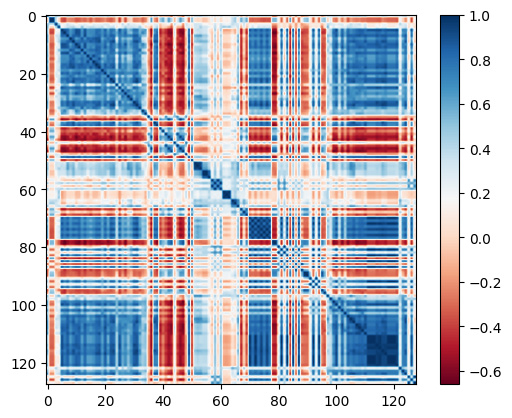

In [12]:
from matplotlib import pyplot as plt
import matplotlib


%matplotlib inline


plt.imshow(lib_match, cmap='RdBu')
plt.colorbar()
plt.show()